### Библиотека pandas для работы с табличными данными

https://pandas.pydata.org/docs/

https://ethanweed.github.io/pythonbook/landingpage.html

In [ ]:
!wget https://phonetics-spbu.github.io/courses/python_genling_bac/files/HollywoodMovies.csv

In [ ]:
import pandas as pd

Создадим датафрейм:

In [ ]:
df = pd.read_csv("HollywoodMovies.csv")

In [6]:
df

,Movie,LeadStudio,RottenTomatoes,AudienceScore,Story,Genre,TheatersOpenWeek,OpeningWeekend,BOAvgOpenWeekend,DomesticGross,ForeignGross,WorldGross,Budget,Profitability,OpenProfit,Year
0,Spider-Man 3,Sony,61.0,54.0,Metamorphosis,Action,4252.0,151.10,35540.0,336.53,554.34,890.87,258.0,345.30,58.57,2007
1,Shrek the Third,Paramount,42.0,57.0,Quest,Animation,4122.0,121.60,29507.0,322.72,476.24,798.96,160.0,499.35,76.00,2007
2,Transformers,Paramount,57.0,89.0,Monster Force,Action,4011.0,70.50,17577.0,319.25,390.46,709.71,150.0,473.14,47.00,2007
3,Pirates of the Caribbean: At World's End,Disney,45.0,74.0,Rescue,Action,4362.0,114.70,26302.0,309.42,654.00,963.42,300.0,321.14,38.23,2007
4,Harry Potter and the Order of the Phoenix,Warner Bros,78.0,82.0,Quest,Adventure,4285.0,77.10,17998.0,292.00,647.88,939.89,150.0,626.59,51.40,2007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,The Canyons,IFC,22.0,NaN,NaN,NaN,1.0,0.01,13351.0,0.06,0.14,0.19,NaN,77.21,NaN,2013
966,The Call,TriStar,43.0,66.0,NaN,NaN,2507.0,17.12,6828.0,51.87,16.70,68.57,13.0,527.48,131.69,2013
967,The English Teacher,Cinedigm Entertainment,42.0,NaN,NaN,NaN,2.0,0.01,3001.0,0.10,0.06,0.10,NaN,NaN,NaN,2013
968,John Dies at the End,Magnolia,61.0,53.0,NaN,NaN,1.0,0.01,12467.0,0.14,NaN,0.14,1.0,14.20,1.00,2013


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Movie             970 non-null    object 
 1   LeadStudio        961 non-null    object 
 2   RottenTomatoes    913 non-null    float64
 3   AudienceScore     907 non-null    float64
 4   Story             641 non-null    object 
 5   Genre             691 non-null    object 
 6   TheatersOpenWeek  949 non-null    float64
 7   OpeningWeekend    969 non-null    float64
 8   BOAvgOpenWeekend  945 non-null    float64
 9   DomesticGross     970 non-null    float64
 10  ForeignGross      876 non-null    float64
 11  WorldGross        914 non-null    float64
 12  Budget            897 non-null    float64
 13  Profitability     896 non-null    float64
 14  OpenProfit        895 non-null    float64
 15  Year              970 non-null    int64  
dtypes: float64(11), int64(1), object(4)
memory u

Извлечём один столбец:

In [9]:
rt_data = df["RottenTomatoes"]
rt_data[:5]

0    61.0
1    42.0
2    57.0
3    45.0
4    78.0
Name: RottenTomatoes, dtype: float64

In [12]:
df["RottenTomatoes"].mean()

np.float64(51.707557502738226)

Извлечём строку:

In [11]:
df.loc[5]

Movie               I Am Legend
LeadStudio          Warner Bros
RottenTomatoes             69.0
AudienceScore              69.0
Story                     Quest
Genre                  Thriller
TheatersOpenWeek         3606.0
OpeningWeekend             77.2
BOAvgOpenWeekend        21411.0
DomesticGross            256.39
ForeignGross             328.96
WorldGross               585.35
Budget                    150.0
Profitability            390.23
OpenProfit                51.47
Year                       2007
Name: 5, dtype: object

Описательные статистики по группам:

In [15]:
df.groupby(["Genre"])["Budget"].agg(["mean", "std", "sem", "count"])

,mean,std,sem,count
Genre,,,,
Action,85.859756,64.025728,4.999569,164
Adventure,80.350000,58.648155,10.707639,30
Animation,108.813725,59.259679,8.298015,51
Biography,35.071429,27.564510,7.366925,14
Comedy,36.896450,26.659866,2.050759,169
Crime,33.320000,20.894811,5.395017,15
Documentary,19.000000,23.950470,10.710976,5
Drama,29.103125,22.943415,2.341653,96
Fantasy,74.450000,61.782643,25.222658,6


In [18]:
corr = df[["RottenTomatoes", "AudienceScore", "WorldGross"]].corr()
corr

,RottenTomatoes,AudienceScore,WorldGross
RottenTomatoes,1.000000,0.702908,0.204155
AudienceScore,0.702908,1.000000,0.383771
WorldGross,0.204155,0.383771,1.000000


Фильтрация:

In [ ]:
horrors = df[df["Genre"] == "Horror"]
horrors

In [31]:
good_movies = df[df["RottenTomatoes"] >= 90]
good_movies

,Movie,LeadStudio,RottenTomatoes,AudienceScore,Story,Genre,TheatersOpenWeek,OpeningWeekend,BOAvgOpenWeekend,DomesticGross,ForeignGross,WorldGross,Budget,Profitability,OpenProfit,Year
6,The Bourne Ultimatum,Universal,93.0,91.0,Pursuit,Thriller,3660.0,69.30,18929.0,227.47,215.35,442.82,110.0,402.57,63.00,2007
10,Ratatouille,Disney,97.0,84.0,Transformation,Animation,3940.0,47.00,11935.0,206.45,417.28,623.72,150.0,415.81,31.33,2007
11,The Simpsons Movie,Fox,90.0,78.0,Maturation,Comedy,3922.0,74.00,18877.0,183.14,343.94,527.07,75.0,702.76,98.67,2007
13,Knocked Up,Universal,91.0,83.0,Love,Comedy,2871.0,30.70,10690.0,148.77,70.31,219.08,33.0,663.86,93.03,2007
14,Juno,Fox,94.0,89.0,Maturation,Comedy,1019.0,10.60,10436.0,143.50,87.92,231.41,7.5,3085.48,141.33,2007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,All Is Lost,Roadside Attractions,93.0,66.0,NaN,NaN,483.0,0.09,194.0,6.22,NaN,6.26,8.5,73.68,1.06,2013
952,Frances Ha,IFC,93.0,78.0,NaN,NaN,233.0,0.14,590.0,4.07,NaN,4.07,7.0,58.14,2.00,2013
955,In a World,Roadside Attractions,92.0,74.0,NaN,NaN,144.0,0.07,490.0,2.96,NaN,2.96,1.0,331.00,7.00,2013
957,No,Sony,93.0,79.0,NaN,NaN,99.0,0.07,725.0,2.34,NaN,2.34,NaN,NaN,NaN,2013


In [33]:
good_horrors = df[(df["RottenTomatoes"] >= 90) & (df["Genre"] == "Horror")]
good_horrors

,Movie,LeadStudio,RottenTomatoes,AudienceScore,Story,Genre,TheatersOpenWeek,OpeningWeekend,BOAvgOpenWeekend,DomesticGross,ForeignGross,WorldGross,Budget,Profitability,OpenProfit,Year
307,Drag Me to Hell,Universal,92.0,61.0,Monster Force,Horror,2508.0,15.80,6310.0,42.10,48.70,90.80,30.0,302.67,52.67,2009
774,The Cabin in the Woods,Lionsgate,92.0,73.0,NaN,Horror,2811.0,14.74,5245.0,42.07,24.41,66.49,30.0,221.62,49.13,2012


In [42]:
df[df["Movie"].str.contains("3")]

,Movie,LeadStudio,RottenTomatoes,AudienceScore,Story,Genre,TheatersOpenWeek,OpeningWeekend,BOAvgOpenWeekend,DomesticGross,ForeignGross,WorldGross,Budget,Profitability,OpenProfit,Year
0,Spider-Man 3,Sony,61.0,54.0,Metamorphosis,Action,4252.0,151.10,35540.0,336.53,554.34,890.870,258.0,345.30,58.57,2007
9,300,Warner Bros,60.0,90.0,Sacrifice,Action,3103.0,70.90,22844.0,210.61,245.45,456.070,65.0,701.64,109.08,2007
15,Rush Hour 3,Warner Bros,20.0,68.0,Rescue,Action,3778.0,49.10,12996.0,140.13,117.90,258.020,140.0,184.30,35.07,2007
25,Ocean's 13,Warner Bros,70.0,74.0,Revenge,Thriller,3565.0,36.10,10135.0,117.15,194.16,311.310,85.0,366.25,42.47,2007
44,3:10 to Yuma,Lionsgate,88.0,85.0,sacrifice,Adventure,2652.0,14.00,5292.0,53.61,16.41,70.020,48.0,145.86,29.17,2007
57,30 Days of Night,Independent,50.0,57.0,Monster Force,Horror,2855.0,15.60,5587.0,39.57,35.94,75.500,32.0,235.95,48.75,2007
122,High School Musical 3: Senior Year,Disney,65.0,76.0,love,Comedy,3623.0,42.03,11601.0,90.56,162.35,252.910,11.0,2299.16,382.09,2008
177,Transporter 3,Independent,36.0,58.0,escape,Action,2626.0,12.06,4594.0,31.72,77.26,108.980,30.0,363.26,40.20,2008
288,The Taking of Pelham 1 2 3,Sony,51.0,60.0,Rescue,Action,3074.0,23.37,7603.0,65.45,84.71,150.160,100.0,150.16,23.37,2009
289,Friday the 13th,Paramount,25.0,52.0,Monster Force,Horror,3105.0,40.60,13066.0,65.00,26.40,91.400,19.0,481.05,213.68,2009


Сортировка:

In [ ]:
horrors_sorted = horrors.sort_values(by=["RottenTomatoes"], ascending=False)
horrors_sorted

Графики:

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

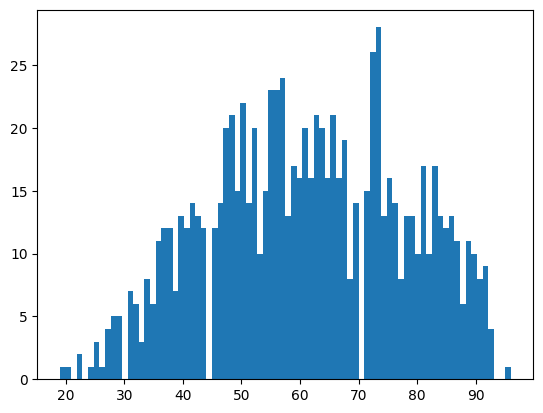

In [28]:
plt.hist(df["AudienceScore"], bins=80)
plt.show()

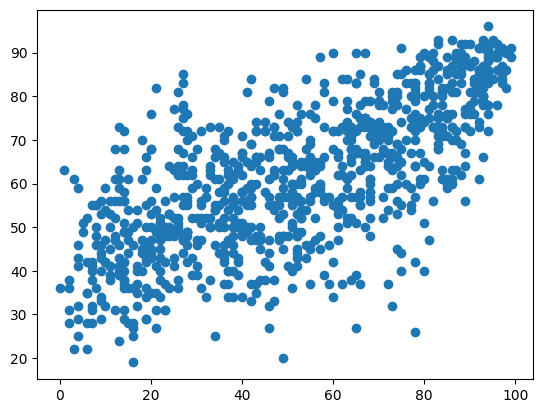

In [58]:
plt.scatter(df["RottenTomatoes"], df["AudienceScore"])

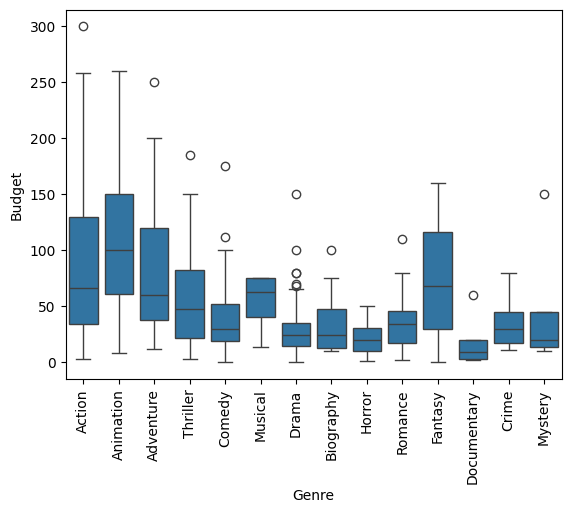

In [27]:
sns.boxplot(df, x="Genre", y="Budget")
plt.xticks(rotation=90)
plt.show()

Кросс-табуляция:

In [51]:
pd.crosstab(index=df["Genre"], columns="count")

col_0,count
Genre,
Action,166
Adventure,30
Animation,51
Biography,14
Comedy,177
Crime,15
Documentary,7
Drama,109
Fantasy,6


In [54]:
pd.crosstab(index=df["LeadStudio"], columns=df["Genre"])

Genre,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Fantasy,Horror,Musical,Mystery,Romance,Thriller
LeadStudio,,,,,,,,,,,,,,
ARC Entertainment,0,0,0,0,0,0,1,1,0,0,0,0,0,0
Aardman Animations,0,0,1,0,0,0,0,0,0,0,0,0,0,0
Atlas Distribution,0,0,0,0,0,0,0,1,0,0,0,0,0,0
Buena Vista,3,1,1,0,1,0,0,0,0,0,0,0,0,0
CBS,1,0,0,0,1,0,0,1,0,0,0,0,1,0
Cohen Media,0,0,0,0,0,0,0,1,0,0,0,0,0,0
Columbia,1,0,0,0,0,0,0,1,0,0,0,0,0,1
Crest,0,0,1,0,0,0,0,0,0,0,0,0,0,0
Disney,10,2,12,0,11,0,0,3,0,0,0,0,0,1


Объединение таблиц:

In [61]:
rus_genres = {
    "Action": "Экшн",
    "Adventure": "Приключения",
    "Animation": "Анимация",
    "Biography": "Биография",
    "Comedy": "Комедия",
    "Crime": "Криминал",
    "Documentary": "Документальное кино",
    "Drama": "Драма",
    "Fantasy": "Фэнтези",
    "Horror": "Ужасы",
    "Musical": "Мюзикл",
    "Mystery": "Мистерия",
    "Romance": "Романтическое кино",
    "Thriller": "Триллер",
}

rus_genres = pd.DataFrame({"Genre": list(rus_genres), "GenreRus": list(rus_genres.values())})
rus_genres

,Genre,GenreRus
0,Action,Экшн
1,Adventure,Приключения
2,Animation,Анимация
3,Biography,Биография
4,Comedy,Комедия
5,Crime,Криминал
6,Documentary,Документальное кино
7,Drama,Драма
8,Fantasy,Фэнтези
9,Horror,Ужасы


In [64]:
new_df = pd.merge(df, rus_genres, on="Genre")
new_df[["Movie", "Genre", "GenreRus"]][:10]

,Movie,Genre,GenreRus
0,Spider-Man 3,Action,Экшн
1,Shrek the Third,Animation,Анимация
2,Transformers,Action,Экшн
3,Pirates of the Caribbean: At World's End,Action,Экшн
4,Harry Potter and the Order of the Phoenix,Adventure,Приключения
5,I Am Legend,Thriller,Триллер
6,The Bourne Ultimatum,Thriller,Триллер
7,National Treasure: Book of Secrets,Thriller,Триллер
8,Alvin and the Chipmunks,Animation,Анимация
9,300,Action,Экшн


### Задания для самостоятельного выполнения

#### Задание 1

Выполните задание 1 с прошлого раза средствами pandas.

а) Постройте гистограмму распределения языков по количеству сегментов на основании таблицы Phoible. Найдите описательные статистики для этих данных.

https://raw.githubusercontent.com/phoible/dev/refs/heads/master/data/phoible.csv

б) Определите языковую семью языков с помощью таблицы Glottolog и постройте гистограммы для трёх самых широко представленных языковых семей.

https://cdstar.eva.mpg.de//bitstreams/EAEA0-608B-9919-A962-0/glottolog_languoid.csv.zip

#### Задание 2

Загрузите данные о городах России.

https://raw.githubusercontent.com/arbaev/russia-cities/refs/heads/master/russia-cities.json

Структуру см. здесь: https://github.com/arbaev/russia-cities

Постройте таблицу со столбцами: город, население, регион, федеральный округ. Постройте таблицу описательных статистик по регионам. Постройте ящики с усами для населения и для количества городов по федеральным округам.